In [ ]:
# ============================================
# PYTHON VISUALIZATION TUTORIAL FOR BEGINNERS
# Matplotlib & Seaborn - Petrophysics Edition
# ============================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set style for better-looking plots
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")

print("=" * 70)
print("PYTHON VISUALIZATION TUTORIAL FOR BEGINNERS")
print("Matplotlib & Seaborn - Petrophysics & Geoscience Examples")
print("=" * 70)


PYTHON VISUALIZATION TUTORIAL FOR BEGINNERS
Matplotlib & Seaborn - Petrophysics & Geoscience Examples


In [ ]:
# --------------------------------------------
# CREATE SAMPLE PETROPHYSICAL DATA
# --------------------------------------------
print("\n[STEP 0] Creating sample petrophysical data...")

np.random.seed(42)  # For reproducible results

# Generate realistic well log data
n_samples = 100
data = {
    'Depth_m': np.linspace(2500, 2600, n_samples),
    'Porosity': np.random.normal(20, 5, n_samples).clip(5, 35),  # %
    'Permeability': np.random.lognormal(3, 1.5, n_samples),       # mD
    'Water_Saturation': np.random.normal(35, 15, n_samples).clip(10, 95),  # %
    'Gamma_Ray': np.random.normal(60, 25, n_samples).clip(20, 150),  # API
    'Formation': np.random.choice(
        ['Sandstone_A', 'Shale_B', 'Limestone_C', 'Sandstone_D'],
        n_samples
    )
}

# Add some correlation between porosity and permeability (realistic)
data['Permeability'] = data['Permeability'] * (data['Porosity'] / 20) ** 2

df = pd.DataFrame(data)
print(f"✓ Created dataset with {len(df)} samples")
print(f"✓ Columns: {list(df.columns)}")
print("\nFirst 5 rows:")
print(df.head())


[STEP 0] Creating sample petrophysical data...
✓ Created dataset with 100 samples
✓ Columns: ['Depth_m', 'Porosity', 'Permeability', 'Water_Saturation', 'Gamma_Ray', 'Formation']

First 5 rows:
       Depth_m   Porosity  Permeability  Water_Saturation  Gamma_Ray  \
0  2500.000000  22.483571      3.037543         40.366810  39.275125   
1  2501.010101  19.308678      9.960993         43.411768  45.995474   
2  2502.020202  23.238443     16.217315         51.245769  78.682340   
3  2503.030303  27.615149     11.494269         50.807031  75.259257   
4  2504.040404  18.829233     13.977210         14.334959  59.477460   

     Formation  
0  Limestone_C  
1  Limestone_C  
2  Sandstone_A  
3  Sandstone_A  
4  Sandstone_D  



SECTION 1: MATPLOTLIB BASICS

[1.1] Creating Line Plot - Porosity vs Depth


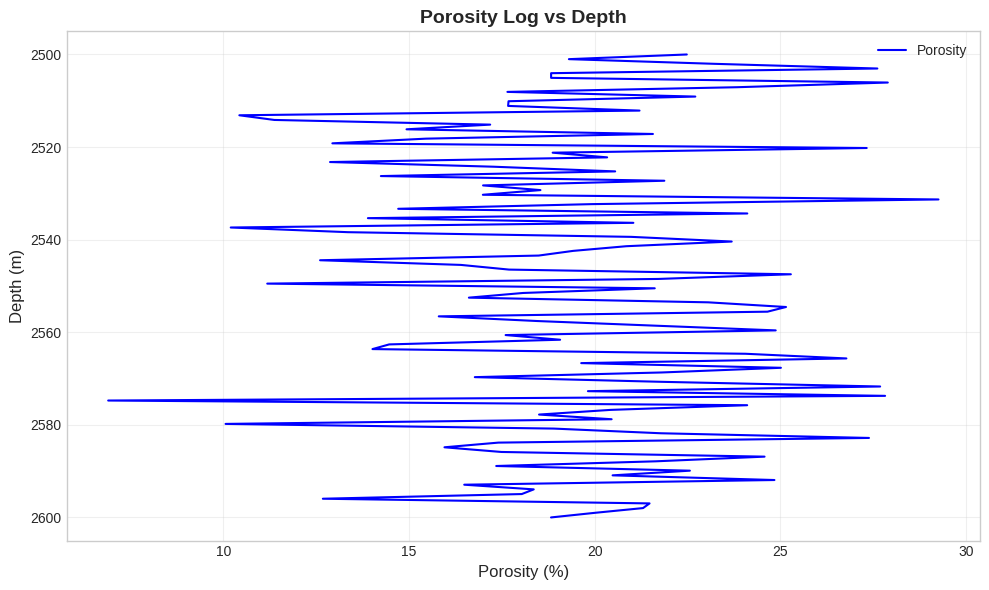

✓ Saved: 01_porosity_depth.png


In [ ]:

# --------------------------------------------
# SECTION 1: MATPLOTLIB BASICS
# --------------------------------------------
print("\n" + "=" * 70)
print("SECTION 1: MATPLOTLIB BASICS")
print("=" * 70)

# --------------------------------------------
# 1.1 Simple Line Plot - Depth Track
# --------------------------------------------
print("\n[1.1] Creating Line Plot - Porosity vs Depth")

plt.figure(figsize=(10, 6))
plt.plot(df['Porosity'],df['Depth_m'], color='blue', linewidth=1.5, label='Porosity')
plt.xlabel('Porosity (%)', fontsize=12)
plt.ylabel('Depth (m)', fontsize=12)
plt.title('Porosity Log vs Depth', fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()  # Depth increases downward
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('01_porosity_depth.png', dpi=300, bbox_inches='tight')
plt.show()
print("✓ Saved: 01_porosity_depth.png")


[1.2] Creating Scatter Plot - Porosity vs Permeability (Crossplot)


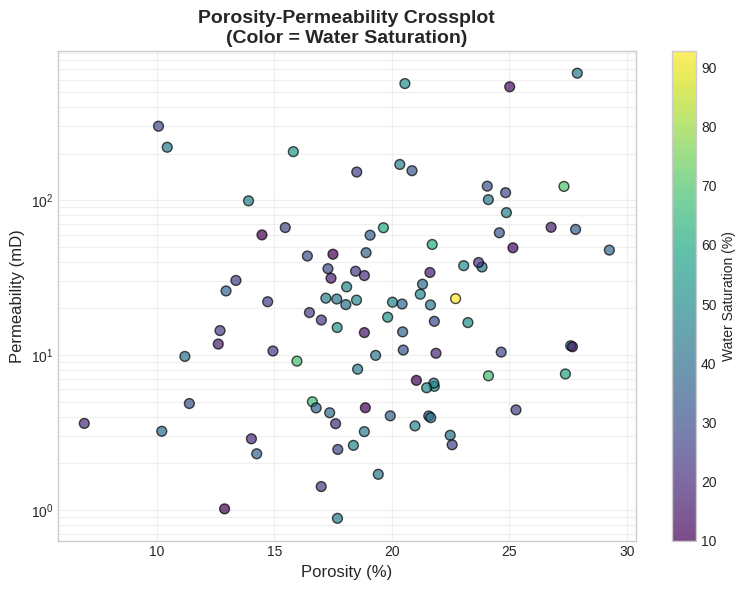

✓ Saved: 02_phi_k_crossplot.png


In [ ]:
# --------------------------------------------
# 1.2 Scatter Plot - Porosity vs Permeability
# --------------------------------------------
print("\n[1.2] Creating Scatter Plot - Porosity vs Permeability (Crossplot)")

plt.figure(figsize=(8, 6))
plt.scatter(df['Porosity'], df['Permeability'],
            c=df['Water_Saturation'], cmap='viridis',
            alpha=0.7, edgecolors='black', s=50)
plt.xlabel('Porosity (%)', fontsize=12)
plt.ylabel('Permeability (mD)', fontsize=12)
plt.title('Porosity-Permeability Crossplot\n(Color = Water Saturation)',
          fontsize=14, fontweight='bold')
plt.xscale('linear')
plt.yscale('log')  # Permeability often plotted on log scale
plt.colorbar(label='Water Saturation (%)')
plt.grid(True, alpha=0.3, which='both')
plt.tight_layout()
plt.savefig('02_phi_k_crossplot.png', dpi=300, bbox_inches='tight')
plt.show()
print("✓ Saved: 02_phi_k_crossplot.png")



[1.3] Creating Histogram - Porosity Distribution


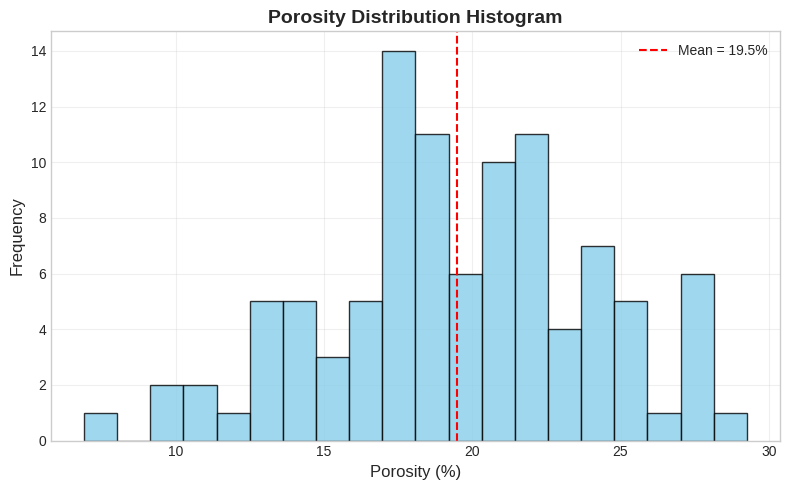

✓ Saved: 03_porosity_histogram.png


In [ ]:
# --------------------------------------------
# 1.3 Histogram - Distribution of Porosity
# --------------------------------------------
print("\n[1.3] Creating Histogram - Porosity Distribution")

plt.figure(figsize=(8, 5))
plt.hist(df['Porosity'], bins=20, color='skyblue', edgecolor='black', alpha=0.8)
plt.xlabel('Porosity (%)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.title('Porosity Distribution Histogram', fontsize=14, fontweight='bold')
plt.axvline(df['Porosity'].mean(), color='red', linestyle='--',
            label=f"Mean = {df['Porosity'].mean():.1f}%")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('03_porosity_histogram.png', dpi=300, bbox_inches='tight')
plt.show()
print("✓ Saved: 03_porosity_histogram.png")


[1.4] Creating Multi-Track Log Display


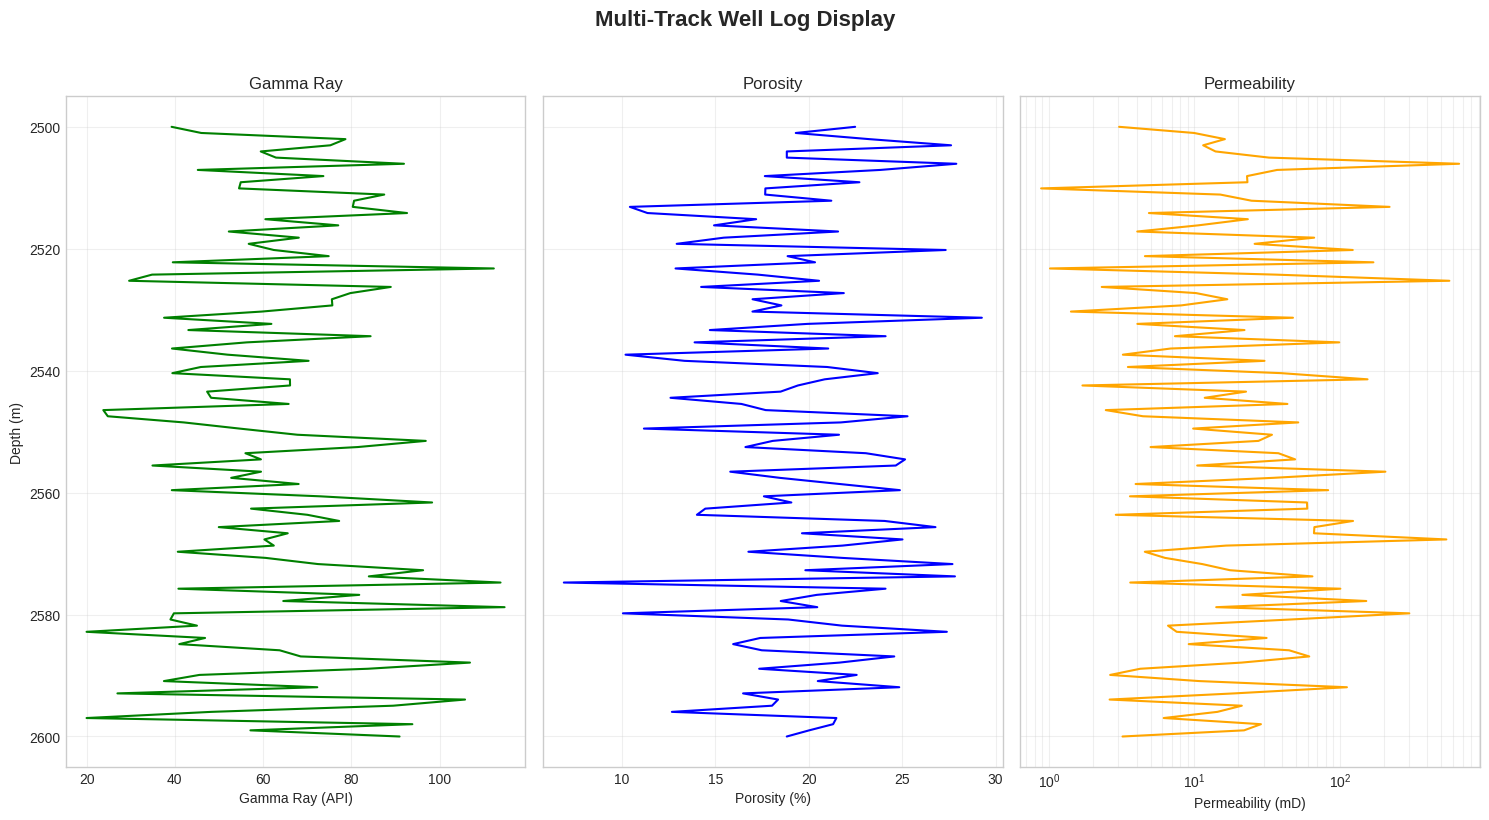

✓ Saved: 04_multi_track_log.png


In [ ]:

# --------------------------------------------
# 1.4 Multiple Lines - Multi-Log Display
# --------------------------------------------
print("\n[1.4] Creating Multi-Track Log Display")

fig, axes = plt.subplots(1, 3, figsize=(15, 8), sharey=True)

# Track 1: Gamma Ray
axes[0].plot(df['Gamma_Ray'], df['Depth_m'], color='green', linewidth=1.5)
axes[0].set_xlabel('Gamma Ray (API)')
axes[0].set_title('Gamma Ray')
axes[0].grid(True, alpha=0.3)
axes[0].invert_yaxis()

# Track 2: Porosity
axes[1].plot(df['Porosity'], df['Depth_m'], color='blue', linewidth=1.5)
axes[1].set_xlabel('Porosity (%)')
axes[1].set_title('Porosity')
axes[1].grid(True, alpha=0.3)
axes[1].invert_yaxis()

# Track 3: Permeability (log scale)
axes[2].plot(df['Permeability'], df['Depth_m'], color='orange', linewidth=1.5)
axes[2].set_xlabel('Permeability (mD)')
axes[2].set_title('Permeability')
axes[2].set_xscale('log')
axes[2].grid(True, alpha=0.3, which='both')
axes[2].invert_yaxis()

# Common y-label
axes[0].set_ylabel('Depth (m)')

plt.suptitle('Multi-Track Well Log Display', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('04_multi_track_log.png', dpi=300, bbox_inches='tight')
plt.show()
print("✓ Saved: 04_multi_track_log.png")



SECTION 2: SEABORN BASICS

[2.1] Seaborn Scatter Plot with Regression Line


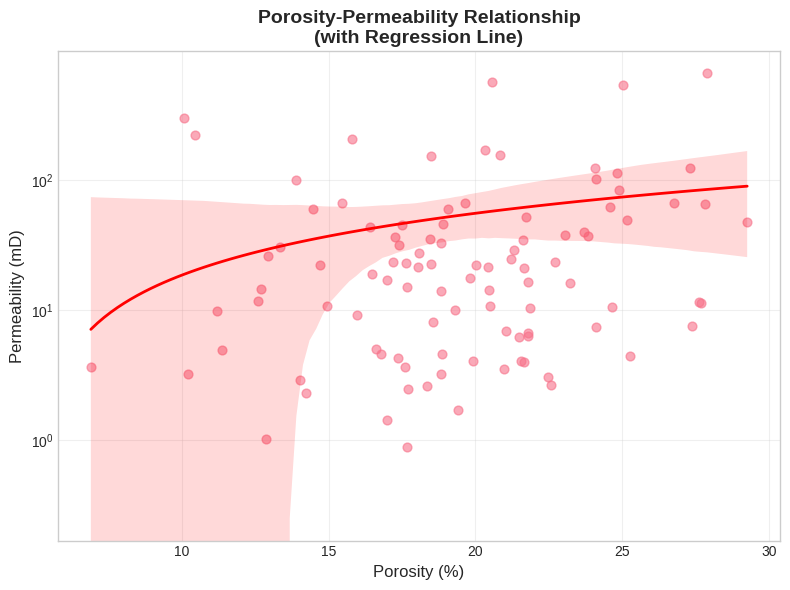

✓ Saved: 05_seaborn_regression.png


In [ ]:

# --------------------------------------------
# SECTION 2: SEABORN BASICS
# --------------------------------------------
print("\n" + "=" * 70)
print("SECTION 2: SEABORN BASICS")
print("=" * 70)

# --------------------------------------------
# 2.1 Enhanced Scatter Plot with Regression
# --------------------------------------------
print("\n[2.1] Seaborn Scatter Plot with Regression Line")

plt.figure(figsize=(8, 6))
sns.regplot(data=df, x='Porosity', y='Permeability',
            scatter_kws={'alpha': 0.6, 's': 40},
            line_kws={'color': 'red', 'linewidth': 2})
plt.xlabel('Porosity (%)', fontsize=12)
plt.ylabel('Permeability (mD)', fontsize=12)
plt.title('Porosity-Permeability Relationship\n(with Regression Line)',
          fontsize=14, fontweight='bold')
plt.yscale('log')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('05_seaborn_regression.png', dpi=300, bbox_inches='tight')
plt.show()
print("✓ Saved: 05_seaborn_regression.png")


[2.2] Seaborn Box Plot - Porosity by Formation


/tmp/ipykernel_750/2329993936.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Formation', y='Porosity',


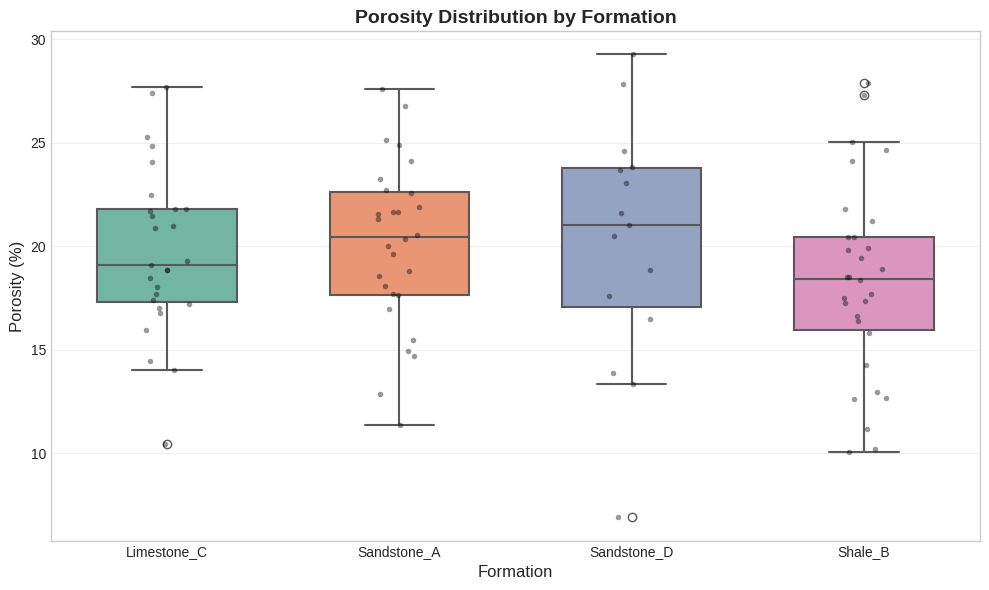

✓ Saved: 06_boxplot_formation.png


In [ ]:
# --------------------------------------------
# 2.2 Box Plot - Compare Formations
# --------------------------------------------
print("\n[2.2] Seaborn Box Plot - Porosity by Formation")

plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='Formation', y='Porosity',
            palette='Set2', width=0.6, linewidth=1.5)
sns.stripplot(data=df, x='Formation', y='Porosity',
              color='black', alpha=0.4, size=4, jitter=True)
plt.xlabel('Formation', fontsize=12)
plt.ylabel('Porosity (%)', fontsize=12)
plt.title('Porosity Distribution by Formation', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig('06_boxplot_formation.png', dpi=300, bbox_inches='tight')
plt.show()
print("✓ Saved: 06_boxplot_formation.png")


[2.3] Seaborn Violin Plot - Permeability by Formation


/tmp/ipykernel_750/2484190271.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x='Formation', y='Permeability',


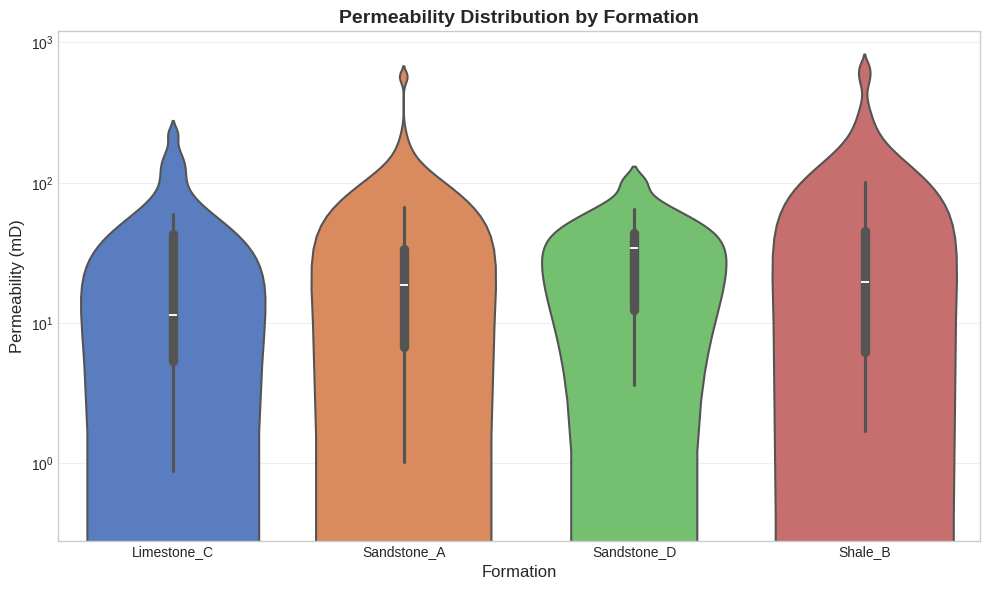

✓ Saved: 07_violin_perm.png


In [ ]:
# --------------------------------------------
# 2.3 Violin Plot - Detailed Distribution
# --------------------------------------------
print("\n[2.3] Seaborn Violin Plot - Permeability by Formation")

plt.figure(figsize=(10, 6))
sns.violinplot(data=df, x='Formation', y='Permeability',
               palette='muted', inner='box', linewidth=1.5)
plt.xlabel('Formation', fontsize=12)
plt.ylabel('Permeability (mD)', fontsize=12)
plt.title('Permeability Distribution by Formation', fontsize=14, fontweight='bold')
plt.yscale('log')
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig('07_violin_perm.png', dpi=300, bbox_inches='tight')
plt.show()
print("✓ Saved: 07_violin_perm.png")


[2.4] Seaborn Pair Plot - Multi-Variable Relationships


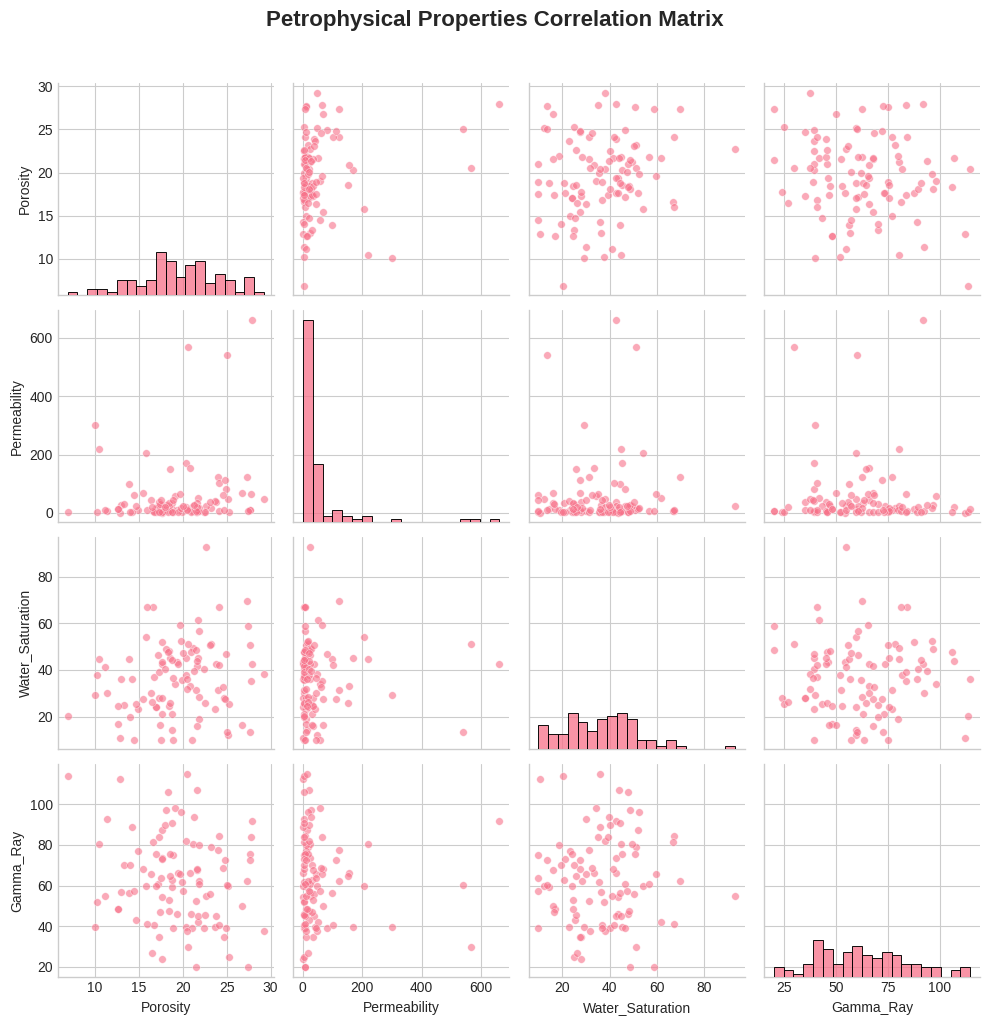

✓ Saved: 08_pairplot.png


In [ ]:
# --------------------------------------------
# 2.4 Pair Plot - Explore Relationships
# --------------------------------------------
print("\n[2.4] Seaborn Pair Plot - Multi-Variable Relationships")

# Select numeric columns for pairplot
numeric_cols = ['Porosity', 'Permeability', 'Water_Saturation', 'Gamma_Ray']
df_subset = df[numeric_cols].copy()

# Create pairplot (may take a moment)
pairplot = sns.pairplot(df_subset,
                        plot_kws={'alpha': 0.6, 's': 30},
                        diag_kws={'bins': 20})
pairplot.fig.suptitle('Petrophysical Properties Correlation Matrix',
                      fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('08_pairplot.png', dpi=300, bbox_inches='tight')
plt.show()
print("✓ Saved: 08_pairplot.png")


[2.5] Seaborn Heatmap - Correlation Matrix


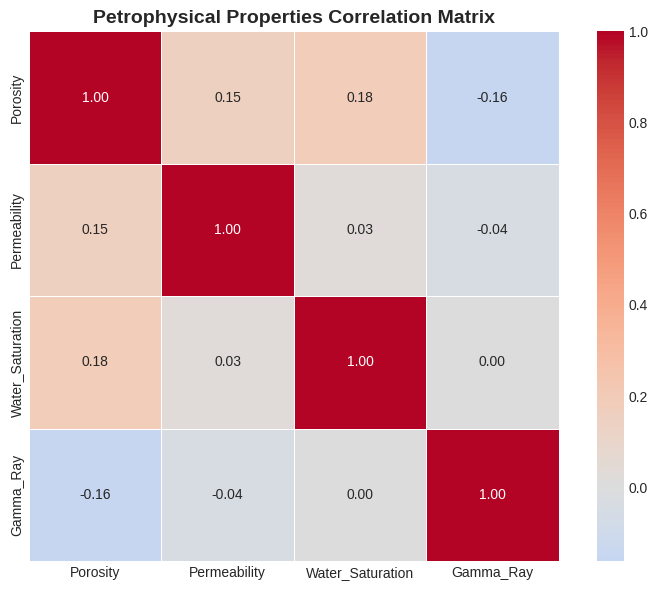

✓ Saved: 09_correlation_heatmap.png


In [ ]:
# --------------------------------------------
# 2.5 Heatmap - Correlation Matrix
# --------------------------------------------
print("\n[2.5] Seaborn Heatmap - Correlation Matrix")

plt.figure(figsize=(8, 6))
corr_matrix = df[numeric_cols].corr()
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, linewidths=0.5)
plt.title('Petrophysical Properties Correlation Matrix',
          fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('09_correlation_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()
print("✓ Saved: 09_correlation_heatmap.png")


SECTION 3: ADVANCED PETROPHYSICAL PLOTS

[3.1] Creating Pickett-Style Plot (Log-Log)


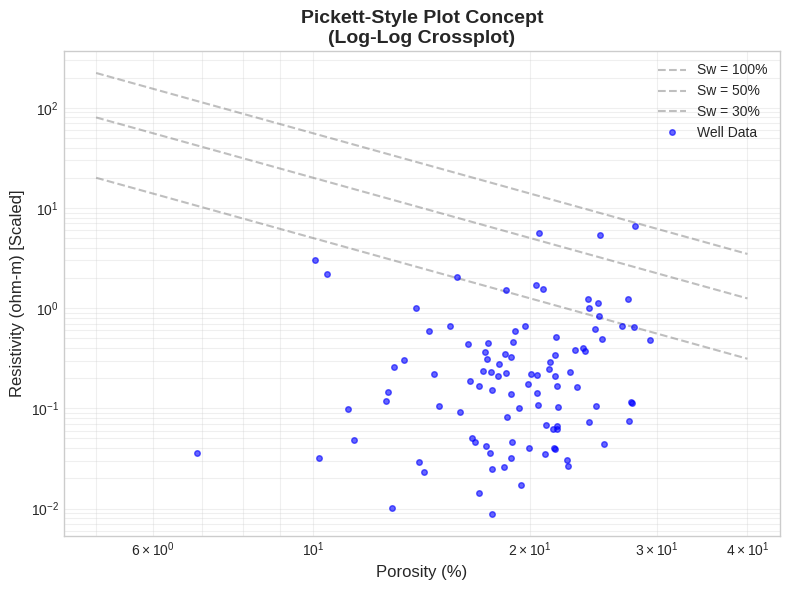

✓ Saved: 10_pickett_concept.png


In [ ]:

# --------------------------------------------
# SECTION 3: ADVANCED PETROPHYSICAL PLOTS
# --------------------------------------------
print("\n" + "=" * 70)
print("SECTION 3: ADVANCED PETROPHYSICAL PLOTS")
print("=" * 70)

# --------------------------------------------
# 3.1 Pickett Plot (Log-Log Crossplot)
# --------------------------------------------
print("\n[3.1] Creating Pickett-Style Plot (Log-Log)")

plt.figure(figsize=(8, 6))

# Create synthetic water line for demonstration
porosity_range = np.linspace(5, 40, 100)
Rw = 0.05  # Formation water resistivity (ohm-m)
m, n = 2.0, 2.0  # Archie parameters
Sw_lines = [1.0, 0.5, 0.3]  # Water saturation lines

for Sw in Sw_lines:
    Rt = (Rw / (Sw ** n)) * (1 / (porosity_range / 100) ** m)
    plt.loglog(porosity_range, Rt, '--', color='gray', alpha=0.5,
               label=f'Sw = {int(Sw*100)}%')

# Plot actual data
plt.loglog(df['Porosity'], df['Permeability'] * 0.01,  # Scaled for demo
           'o', color='blue', alpha=0.6, label='Well Data', markersize=4)

plt.xlabel('Porosity (%)', fontsize=12)
plt.ylabel('Resistivity (ohm-m) [Scaled]', fontsize=12)
plt.title('Pickett-Style Plot Concept\n(Log-Log Crossplot)',
          fontsize=14, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3, which='both')
plt.tight_layout()
plt.savefig('10_pickett_concept.png', dpi=300, bbox_inches='tight')
plt.show()
print("✓ Saved: 10_pickett_concept.png")


[3.2] Creating Color-Coded Depth Track (Lithology)


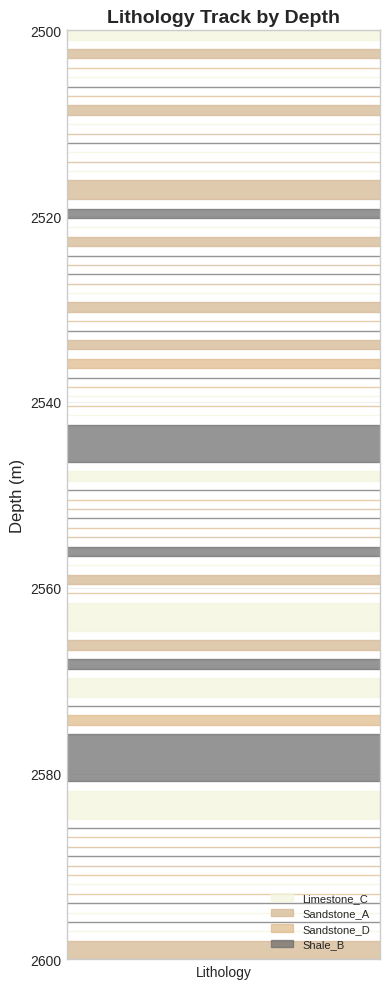

✓ Saved: 11_lithology_track.png


In [ ]:

# --------------------------------------------
# 3.2 Color-Coded Depth Track
# --------------------------------------------
print("\n[3.2] Creating Color-Coded Depth Track (Lithology)")

plt.figure(figsize=(4, 10))

# Color mapping for formations
color_map = {'Sandstone_A': '#D2B48C', 'Shale_B': '#696969',
             'Limestone_C': '#F5F5DC', 'Sandstone_D': '#DEB887'}

for formation in df['Formation'].unique():
    mask = df['Formation'] == formation
    plt.fill_betweenx(df['Depth_m'], 0, 1,
                      where=mask,
                      color=color_map.get(formation, 'white'),
                      alpha=0.7, label=formation)

plt.xlim(0, 1)
plt.ylim(df['Depth_m'].max(), df['Depth_m'].min())  # Invert y for depth
plt.xlabel('Lithology', fontsize=10)
plt.ylabel('Depth (m)', fontsize=12)
plt.title('Lithology Track by Depth', fontsize=14, fontweight='bold')
plt.legend(loc='lower right', fontsize=8)
plt.xticks([])  # Hide x-ticks
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig('11_lithology_track.png', dpi=300, bbox_inches='tight')
plt.show()
print("✓ Saved: 11_lithology_track.png")


[3.3] Histogram with KDE Overlay


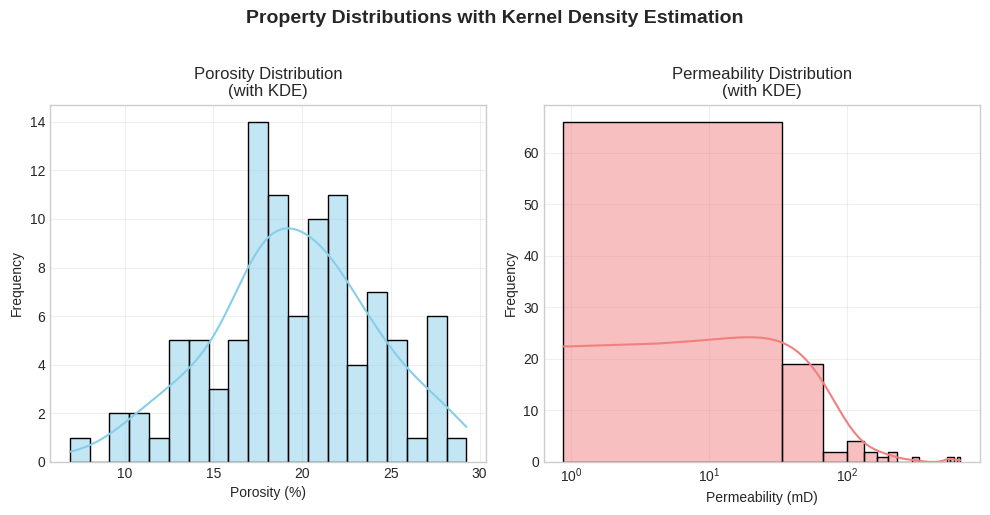

✓ Saved: 12_histograms_kde.png


In [ ]:
# --------------------------------------------
# 3.3 Histogram with KDE (Kernel Density)
# --------------------------------------------
print("\n[3.3] Histogram with KDE Overlay")

plt.figure(figsize=(10, 5))

# Porosity histogram with KDE
plt.subplot(1, 2, 1)
sns.histplot(data=df, x='Porosity', bins=20, kde=True,
             color='skyblue', edgecolor='black')
plt.xlabel('Porosity (%)')
plt.ylabel('Frequency')
plt.title('Porosity Distribution\n(with KDE)')
plt.grid(True, alpha=0.3)

# Permeability histogram with KDE (log scale)
plt.subplot(1, 2, 2)
sns.histplot(data=df, x='Permeability', bins=20, kde=True,
             color='lightcoral', edgecolor='black')
plt.xlabel('Permeability (mD)')
plt.ylabel('Frequency')
plt.title('Permeability Distribution\n(with KDE)')
plt.xscale('log')
plt.grid(True, alpha=0.3)

plt.suptitle('Property Distributions with Kernel Density Estimation',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('12_histograms_kde.png', dpi=300, bbox_inches='tight')
plt.show()
print("✓ Saved: 12_histograms_kde.png")

In [ ]:
# --------------------------------------------
# SECTION 4: EXPORT & CUSTOMIZATION TIPS
# --------------------------------------------
print("\n" + "=" * 70)
print("SECTION 4: EXPORT & CUSTOMIZATION TIPS")
print("=" * 70)

print("""
📁 EXPORT OPTIONS:
  • plt.savefig('filename.png', dpi=300, bbox_inches='tight')  # High-res PNG
  • plt.savefig('filename.pdf', bbox_inches='tight')           # Vector PDF
  • plt.savefig('filename.svg', bbox_inches='tight')           # Scalable SVG

🎨 CUSTOMIZATION QUICK REFERENCE:
  • figsize=(width, height)          - Control plot size in inches
  • dpi=300                          - Resolution for publication quality
  • alpha=0.7                        - Transparency (0=transparent, 1=opaque)
  • cmap='viridis'                   - Color map options: viridis, plasma, coolwarm
  • fontsize=12                      - Text size for labels/titles
  • linewidth=2                      - Line thickness
  • s=50                             - Scatter point size
  • edgecolors='black'               - Point border color

🔧 COMMON PETROPHYSICAL STYLING:
  • Depth axis: plt.gca().invert_yaxis()  # Depth increases downward
  • Permeability: plt.yscale('log')       # Log scale for wide ranges
  • Porosity limits: plt.xlim(0, 40)      # Typical porosity range
  • Grid: plt.grid(True, alpha=0.3)       # Subtle grid lines
""")

# --------------------------------------------
# SECTION 5: QUICK START TEMPLATE
# --------------------------------------------
print("\n" + "=" * 70)
print("SECTION 5: QUICK START TEMPLATE FOR YOUR DATA")
print("=" * 70)

template_code = '''
# ============================================
# QUICK START: VISUALIZE YOUR PETROPHYSICAL DATA
# ============================================

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. LOAD YOUR DATA
df = pd.read_csv('your_well_data.csv')  # or .LAS converted to CSV

# 2. BASIC SCATTER PLOT (Porosity vs Permeability)
plt.figure(figsize=(8, 6))
plt.scatter(df['Porosity'], df['Permeability'], alpha=0.7)
plt.xlabel('Porosity (%)')
plt.ylabel('Permeability (mD)')
plt.yscale('log')  # Important for permeability!
plt.grid(True, alpha=0.3)
plt.title('Your Well: Porosity-Permeability Crossplot')
plt.savefig('my_crossplot.png', dpi=300)
plt.show()

# 3. HISTOGRAM OF POROSITY
plt.figure(figsize=(8, 5))
sns.histplot(data=df, x='Porosity', bins=20, kde=True)
plt.xlabel('Porosity (%)')
plt.title('Porosity Distribution')
plt.grid(True, alpha=0.3)
plt.savefig('my_porosity_hist.png', dpi=300)
plt.show()

# 4. DEPTH TRACK FOR ANY LOG
plt.figure(figsize=(6, 10))
plt.plot(df['Your_Log_Column'], df['Depth'], color='blue')
plt.xlabel('Your Log Units')
plt.ylabel('Depth (m)')
plt.gca().invert_yaxis()  # Depth goes down!
plt.title('Your Log vs Depth')
plt.grid(True, alpha=0.3)
plt.savefig('my_depth_track.png', dpi=300)
plt.show()

# 5. BOX PLOT BY FORMATION
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='Formation', y='Porosity')
plt.xlabel('Formation')
plt.ylabel('Porosity (%)')
plt.title('Porosity by Formation')
plt.savefig('my_formation_boxplot.png', dpi=300)
plt.show()
'''

print(template_code)

# --------------------------------------------
# FINAL SUMMARY
# --------------------------------------------
print("\n" + "=" * 70)
print("TUTORIAL COMPLETED!")
print("=" * 70)

print("\n✅ What You Learned:")
print("  1. Basic matplotlib: line plots, scatter plots, histograms")
print("  2. Multi-track log displays with shared depth axis")
print("  3. Seaborn: regression plots, box plots, violin plots")
print("  4. Advanced: pair plots, correlation heatmaps, Pickett-style plots")
print("  5. Petrophysics-specific: log scales, depth inversion, lithology tracks")
print("  6. Export options for reports and publications")

print("\n📁 Files Created (12 visualization examples):")
output_files = [
    '01_porosity_depth.png',
    '02_phi_k_crossplot.png',
    '03_porosity_histogram.png',
    '04_multi_track_log.png',
    '05_seaborn_regression.png',
    '06_boxplot_formation.png',
    '07_violin_perm.png',
    '08_pairplot.png',
    '09_correlation_heatmap.png',
    '10_pickett_concept.png',
    '11_lithology_track.png',
    '12_histograms_kde.png'
]
for f in output_files:
    print(f"  • {f}")

print("\n🔑 Key Petrophysics Visualization Tips:")
print("  • Always invert y-axis for depth: plt.gca().invert_yaxis()")
print("  • Use log scale for permeability: plt.yscale('log')")
print("  • Color-code by lithology or water saturation for insights")
print("  • Use KDE with histograms to see distribution shape")
print("  • Export with dpi=300 for publication-quality figures")

print("\n" + "=" * 70)
print("NEXT STEPS:")
print("=" * 70)
print("1. Replace sample data with your well log CSV/LAS data")
print("2. Adjust column names to match your dataset")
print("3. Customize colors, labels, and styles for your reports")
print("4. Combine plots into multi-panel figures for presentations")
print("5. Explore interactive plots with plotly for dashboards")
print("=" * 70)


SECTION 4: EXPORT & CUSTOMIZATION TIPS

📁 EXPORT OPTIONS:
  • plt.savefig('filename.png', dpi=300, bbox_inches='tight')  # High-res PNG
  • plt.savefig('filename.pdf', bbox_inches='tight')           # Vector PDF
  • plt.savefig('filename.svg', bbox_inches='tight')           # Scalable SVG

🎨 CUSTOMIZATION QUICK REFERENCE:
  • figsize=(width, height)          - Control plot size in inches
  • dpi=300                          - Resolution for publication quality
  • alpha=0.7                        - Transparency (0=transparent, 1=opaque)
  • cmap='viridis'                   - Color map options: viridis, plasma, coolwarm
  • fontsize=12                      - Text size for labels/titles
  • linewidth=2                      - Line thickness
  • s=50                             - Scatter point size
  • edgecolors='black'               - Point border color

🔧 COMMON PETROPHYSICAL STYLING:
  • Depth axis: plt.gca().invert_yaxis()  # Depth increases downward
  • Permeability: plt.yscale('log